In [1]:
pip install -q librosa soundfile numpy pandas scikit-learn tensorflow matplotlib seaborn praat-parselmouth tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import time
import random
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import parselmouth
from parselmouth.praat import call
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix,f1_score, recall_score, precision_score,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

/usr/local/python/3.14.2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

BASE_DIR = './datasets/' 
SAMPLE_RATE = 16000
EMOTION_LABELS = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgusted', 'surprised']
NUM_CLASSES = len(EMOTION_LABELS)
EPOCHS = 50
BATCH_SIZE = 32



In [5]:
DATASET_PATHS = {
    'RAVDESS': os.path.join(BASE_DIR),
    'TESS':    os.path.join(BASE_DIR),
    'EmoDB':   os.path.join(BASE_DIR),
}

In [6]:
missing = []
for name, path in DATASET_PATHS.items():
    if os.path.isdir(path):
        n_wav = len(glob.glob(os.path.join(path, '**', '*.wav'), recursive=True))
        print(f"[OK]      {name:8s} -> {n_wav:5d} .wav files found in '{path}'")
    else:
        missing.append(name)
        print(f"[MISSING] {name:8s} -> folder not found at '{path}'")

[OK]      RAVDESS  ->  4775 .wav files found in './datasets/'
[OK]      TESS     ->  4775 .wav files found in './datasets/'
[OK]      EmoDB    ->  4775 .wav files found in './datasets/'


In [8]:
RAVDESS_EMO_MAP = {
    '01': 'neutral',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust',
}

ravdess_records, ravdess_skipped = [], 0

for fp in glob.glob(os.path.join(DATASET_PATHS['RAVDESS'], '**', '*.wav'), recursive=True):
    fname = os.path.basename(fp)
    parts = fname.split('-')
    
    if len(parts) == 7 and parts[0] == '03' and parts[1] == '01':
        emo = RAVDESS_EMO_MAP.get(parts[2])
        if emo is not None:
            ravdess_records.append({'filepath': fp, 'emotion': emo, 'dataset': 'RAVDESS'})
        else:
            ravdess_skipped += 1         
    else:
        ravdess_skipped += 1          


In [9]:
TESS_EMO_MAP = {
    'angry':   'angry',
    'disgust': 'disgust',
    'fear':    'fear',
    'happy':   'happy',
    'neutral': 'neutral',
    'sad':     'sad',
}

In [10]:
tess_records, tess_skipped = [], 0

for fp in glob.glob(os.path.join(DATASET_PATHS['TESS'], '**', '*.wav'), recursive=True):
    fname = os.path.basename(fp)
    stem = os.path.splitext(fname)[0]
    tokens = stem.split('_')
    if len(tokens) >= 3:
        emo = TESS_EMO_MAP.get(tokens[-1].strip().lower())
        if emo is not None:
            tess_records.append({'filepath': fp, 'emotion': emo, 'dataset': 'TESS'})
        else:
            tess_skipped += 1           
    else:
        tess_skipped += 1                 


In [11]:
EMODB_EMO_MAP = {
    'W': 'angry',
    'E': 'disgust',
    'A': 'fear',
    'F': 'happy',
    'T': 'sad',
    'N': 'neutral',
}

emodb_records, emodb_skipped = [], 0

for fp in glob.glob(os.path.join(DATASET_PATHS['EmoDB'], '**', '*.wav'), recursive=True):
    fname = os.path.basename(fp)
    stem = os.path.splitext(fname)[0]
    if len(stem) >= 6:
        emo = EMODB_EMO_MAP.get(stem[5].upper())
        if emo is not None:
            emodb_records.append({'filepath': fp, 'emotion': emo, 'dataset': 'EmoDB'})
        else:
            emodb_skipped += 1           
    else:
        emodb_skipped += 1                


In [12]:
all_records = ravdess_records + tess_records + emodb_records
df = pd.DataFrame(all_records, columns=['filepath', 'emotion', 'dataset'])

In [13]:
before = len(df)
df = df[df['filepath'].apply(os.path.isfile)].reset_index(drop=True)
if before - len(df):
    print(f"Removed {before - len(df)} records pointing to missing files.")

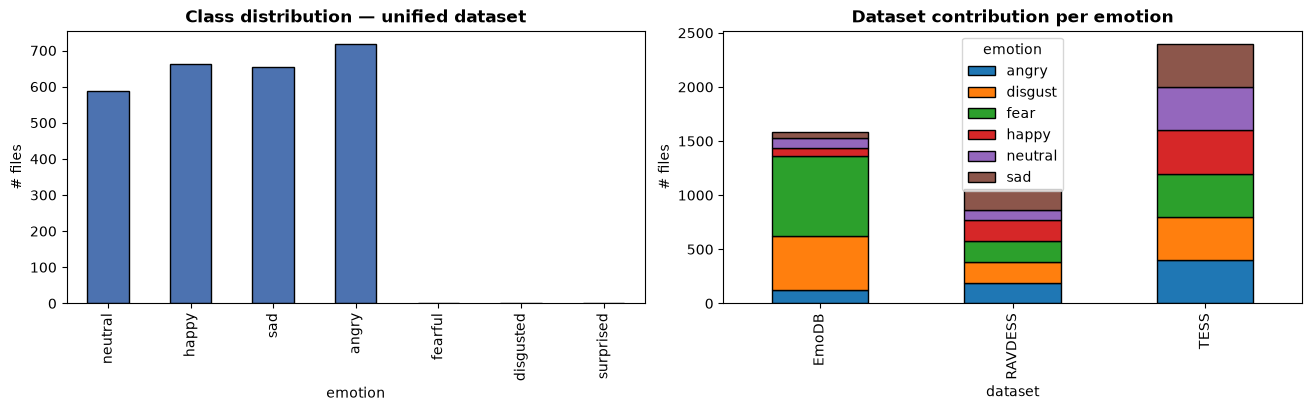

,filepath,emotion
0,./datasets/RAVDESS/Actor_20/03-01-06-01-02-02-...,fear
1,./datasets/RAVDESS/Actor_20/03-01-03-01-02-02-...,happy
2,./datasets/RAVDESS/Actor_20/03-01-06-01-01-02-...,fear
3,./datasets/RAVDESS/Actor_20/03-01-05-01-02-01-...,angry
4,./datasets/RAVDESS/Actor_20/03-01-04-01-01-02-...,sad
5,./datasets/RAVDESS/Actor_20/03-01-04-01-02-02-...,sad
6,./datasets/RAVDESS/Actor_20/03-01-07-02-01-01-...,disgust
7,./datasets/RAVDESS/Actor_20/03-01-06-01-01-01-...,fear
8,./datasets/RAVDESS/Actor_20/03-01-03-02-01-02-...,happy
9,./datasets/RAVDESS/Actor_20/03-01-03-01-01-01-...,happy


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
df['emotion'].value_counts().reindex(EMOTION_LABELS).plot(
    kind='bar', ax=axes[0], color='#4C72B0', edgecolor='black')
axes[0].set_title('Class distribution — unified dataset', fontweight='bold')
axes[0].set_ylabel('# files')

pd.crosstab(df['dataset'], df['emotion']).plot(
    kind='bar', stacked=True, ax=axes[1], edgecolor='black')
axes[1].set_title('Dataset contribution per emotion', fontweight='bold')
axes[1].set_ylabel('# files')
plt.show()

df[['filepath', 'emotion']].head(10)

In [18]:
HINTS = {
    'NoBackendError':    'No decoder could read this file. If it is MP3/OGG (or another '
                         'non-PCM format renamed to .wav): with librosa 0.10.x install the '
                         'fallback backend (%pip install audioread, requires ffmpeg); with '
                         'librosa >= 0.11 audioread support was removed — convert the audio '
                         'to standard PCM WAV instead.',
    'LibsndfileError':   'libsndfile could not decode the file — it is usually CORRUPT or '
                         'truncated (check the byte size above; 0 bytes = broken download). '
                         'Re-extract the archive or re-download that file.',
    'FileNotFoundError': 'The path recorded in Step 3 no longer exists — files were moved or '
                         'renamed after mining. Re-run the Step 3 cells.',
    'RuntimeError':      'Audio could not be decoded by any available backend. '
                         'Try %pip install audioread, or convert the file to PCM WAV.',
    'EOFError':          'File is truncated / incomplete — re-download it.',
}

In [19]:
def probe_file(fp):
    """Diagnose one audio file. Returns (ok, report_lines). Never raises."""
    lines = []
    try:
        size = os.path.getsize(fp)
        if size == 0:
            lines.append('      x 0-byte file (broken download) -> re-download / re-extract')
            return False, lines
        lines.append(f'      size: {size / 1024:.1f} KB')

        # Container-level inspection (no decode): format, bit depth, rate, channels
        try:
            info = sf.info(fp)
            lines.append(f'      format: {info.format} / {info.subtype} | {info.samplerate} Hz | '
                         f'{info.channels} ch | {info.frames / info.samplerate:.2f}s')
        except Exception as e:
            lines.append(f'      format probe failed ({type(e).__name__}: {e})')

        # Full decode round-trip — the exact operation Step 4 performs
        y, sr = librosa.load(fp, sr=SAMPLE_RATE, mono=True)
        lines.append(f'      decoded OK -> {len(y)} samples @ {sr} Hz, mono, '
                     f'{len(y) / sr:.2f}s, peak {np.max(np.abs(y)):.3f}')
        return True, lines

    except Exception as e:
        lines.append(f'      FAILED: {type(e).__name__}: {e}')
        hint = next((h for key, h in HINTS.items()
                     if key.lower() in type(e).__name__.lower()), None)
        if hint is None and 'to load audio' in str(e).lower():
            hint = HINTS['NoBackendError']
        if hint:
            lines.append(f'        hint: {hint}')
        return False, lines


for name in ['RAVDESS', 'TESS', 'EmoDB']:
    subset = df[df['dataset'] == name]['filepath']
    if subset.empty:
        print(f'{name}: no files available (skipping check)')
        continue
    print(f'\n{name}:')
    samples = list(subset.iloc[:3])                 # probe up to 3 files per corpus
    ok_count = 0
    for fp in samples:
        ok, report = probe_file(fp)
        print(f'  {os.path.basename(fp)}')
        for line in report:
            print(line)
        ok_count += ok
    verdict = ('ALL SAMPLES LOADABLE — standardisation pipeline confirmed'
               if ok_count == len(samples)
               else 'SOME SAMPLES FAILED — read the hints above; '
                    'Step 4 will skip bad files automatically')
    print(f'  => {ok_count}/{len(samples)} samples loadable | {verdict}')


RAVDESS:
  03-01-06-01-02-02-20.wav
      size: 0.1 KB
      format probe failed (LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-06-01-02-02-20.wav': Format not recognised.)
      FAILED: LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-06-01-02-02-20.wav': Format not recognised.
        hint: libsndfile could not decode the file — it is usually CORRUPT or truncated (check the byte size above; 0 bytes = broken download). Re-extract the archive or re-download that file.
  03-01-03-01-02-02-20.wav
      size: 0.1 KB
      format probe failed (LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-03-01-02-02-20.wav': Format not recognised.)
      FAILED: LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-03-01-02-02-20.wav': Format not recognised.
        hint: libsndfile could not decode the file — it is usually CORRUPT or truncated (check the byte size above; 0 bytes = broken download). Re-extract the archive or re-download

In [20]:
FEATURE_NAMES = (
    [f'mfcc_{i + 1:02d}' for i in range(40)] +                        #  40  MFCC means
    ['spectral_centroid', 'spectral_rolloff'] +                       #   2  brightness / roll-off
    [f'spectral_contrast_{i + 1}' for i in range(7)] +                #   7  contrast bands
    [f'mel_{i + 1:03d}' for i in range(128)] +                        # 128  mel-band means
    ['rms_energy', 'zcr'] +                                           #   2  prosodic (librosa)
    ['f0_mean', 'f0_variance'] +                                      #   2  pitch statistics
    ['formant_f1', 'formant_f2', 'formant_f3'] +                      #   3  formant means
    ['jitter_local', 'shimmer_local', 'hnr']                          #   3  voice quality
)
N_FEATURES = len(FEATURE_NAMES)                                       # 187


def extract_librosa_features(y, sr):
    """Spectral + prosodic frame-level features, summarised by their time-mean."""
    feats = []
    feats.extend(np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40), axis=1))    # 40 MFCCs
    feats.append(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))          # brightness
    feats.append(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))           # 85 % roll-off
    feats.extend(np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1))  # 7 bands
    feats.extend(np.mean(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128), axis=1))
    feats.append(np.mean(librosa.feature.rms(y=y)))                               # loudness
    feats.append(np.mean(librosa.feature.zero_crossing_rate(y=y)))                # ZCR
    return np.asarray(feats, dtype=np.float64)


def extract_parselmouth_features(y, sr):
    """Prosodic (F0, formants) + voice-quality (jitter, shimmer, HNR) via Praat."""
    snd = parselmouth.Sound(np.asarray(y, dtype=np.float64), sampling_frequency=sr)
    feats = []

    # --- F0 statistics (pitch floor 75 Hz, ceiling 600 Hz) ---
    pitch = call(snd, 'To Pitch', 0.0, 75, 600)
    f0_mean = call(pitch, 'Get mean', 0, 0, 'Hertz')
    f0_std = call(pitch, 'Get standard deviation', 0, 0, 'Hertz')
    feats.extend([f0_mean, f0_std ** 2])                    # variance = std²

    # --- Formants F1-F3: sample at 25/50/75 % of the utterance, average ---
    formant = call(snd, 'To Formant (burg)', 0.0, 5, 5500, 0.025, 50)
    duration = snd.get_total_duration()
    for formant_idx in (1, 2, 3):
        samples = [call(formant, 'Get value at time', formant_idx, t, 'Hertz', 'Linear')
                   for t in (0.25 * duration, 0.5 * duration, 0.75 * duration)]
        samples = [s for s in samples if s is not None and np.isfinite(s)]
        feats.append(np.mean(samples) if samples else np.nan)

    # --- Voice quality: jitter (cycle-to-cycle F0 variation) ---
    point_process = call(snd, 'To PointProcess (periodic, cc)', 75, 600)
    feats.append(call(point_process, 'Get jitter (local)', 0, 0, 0.0001, 0.02, 1.3))
    # --- ... shimmer (cycle-to-cycle amplitude variation) ---
    feats.append(call([snd, point_process], 'Get shimmer (local)', 0, 0, 0.0001, 0.02, 1.3, 1.6))
    # --- ... harmonics-to-noise ratio (dB) ---
    harmonicity = call(snd, 'To Harmonicity (cc)', 0.01, 75, 0.1, 1.0)
    feats.append(call(harmonicity, 'Get mean', 0, 0))

    return np.asarray(feats, dtype=np.float64)


def extract_features(filepath):
    """Full 187-dim vector for one file. Returns None if the file must be skipped."""
    try:
        # Standardisation happens HERE: mono 16 kHz float32 in [-1, 1]
        y, sr = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
        if len(y) < 2048:                                   # < ~128 ms -> unstable statistics
            print(f'  [SKIP] {os.path.basename(filepath)} — too short ({len(y)} samples)')
            return None

        lib_feats = extract_librosa_features(y, sr)
        try:
            pm_feats = extract_parselmouth_features(y, sr)
        except Exception as pm_err:
            # Praat can fail on pathological clips: keep the file,
            # but let the 8 prosodic/voice-quality dims fall back to 0.
            print(f'  [WARN] parselmouth failed on {os.path.basename(filepath)}: {pm_err}')
            pm_feats = np.full(8, np.nan)

        feats = np.concatenate([lib_feats, pm_feats])
        feats = np.where(np.isfinite(feats), feats, 0.0)    # NaN / inf -> 0
        return feats

    except Exception as e:
        print(f'  [SKIP] {os.path.basename(filepath)} — {type(e).__name__}: {e}')
        return None


print(f'Feature vector defined: {N_FEATURES} dimensions per utterance.')

Feature vector defined: 187 dimensions per utterance.


In [21]:
features_list, kept_positions = [], []

for pos, row in tqdm(df.iterrows(), total=len(df), desc='Extracting features'):
    vec = extract_features(row['filepath'])
    if vec is not None:
        features_list.append(vec)
        kept_positions.append(pos)

if not features_list:
    raise RuntimeError('No audio file was processed successfully — '
                       'verify DATASET_PATHS in Step 2.')

# Keep only the rows that were actually processed (preserves filepath/emotion order)
df = df.loc[kept_positions].reset_index(drop=True)

X_all = np.vstack(features_list)
features_df = pd.DataFrame(X_all, columns=FEATURE_NAMES)

# Convenience checkpoint — lets later steps re-run without re-extracting
features_df.to_csv('extracted_features.csv', index=False)

print(f'\nExtraction finished: {features_df.shape[0]} files × {features_df.shape[1]} features')
print(f"Saved feature checkpoint -> {os.path.abspath('extracted_features.csv')}")
display(features_df.describe().T.iloc[:12])   # preview statistics of the first 12 dims

Extracting features:   0%|          | 0/5044 [00:00<?, ?it/s]

  [SKIP] 03-01-06-01-02-02-20.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-06-01-02-02-20.wav': Format not recognised.
  [SKIP] 03-01-03-01-02-02-20.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-03-01-02-02-20.wav': Format not recognised.
  [SKIP] 03-01-06-01-01-02-20.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-06-01-01-02-20.wav': Format not recognised.
  [SKIP] 03-01-05-01-02-01-20.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-05-01-02-01-20.wav': Format not recognised.
  [SKIP] 03-01-04-01-01-02-20.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-04-01-01-02-20.wav': Format not recognised.
  [SKIP] 03-01-04-01-02-02-20.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-04-01-02-02-20.wav': Format not recognised.
  [SKIP] 03-01-07-02-01-01-20.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_20/03-01-07-02-01-01-20.wav': F

Extracting features:   2%|▏         | 82/5044 [00:00<00:23, 215.53it/s]

  [SKIP] 03-01-01-01-01-01-07.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_07/03-01-01-01-01-01-07.wav': Format not recognised.
  [SKIP] 03-01-03-02-02-02-07.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_07/03-01-03-02-02-02-07.wav': Format not recognised.
  [SKIP] 03-01-03-01-02-01-07.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_07/03-01-03-01-02-01-07.wav': Format not recognised.
  [SKIP] 03-01-01-01-02-01-07.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_07/03-01-01-01-02-01-07.wav': Format not recognised.
  [SKIP] 03-01-03-02-01-02-07.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_07/03-01-03-02-01-02-07.wav': Format not recognised.
  [SKIP] 03-01-05-02-02-01-07.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_07/03-01-05-02-02-01-07.wav': Format not recognised.
  [SKIP] 03-01-01-01-01-02-07.wav — LibsndfileError: Error opening './datasets/RAVDESS/Actor_07/03-01-01-01-01-02-07.wav': F

Extracting features:   4%|▍         | 222/5044 [00:00<00:10, 448.38it/s]

...

Extracting features:  92%|█████████▏| 4636/5044 [00:03<00:00, 2900.30it/s]

  [SKIP] YAF_fat_neutral.wav — LibsndfileError: Error opening './datasets/TESS/YAF_fat_neutral.wav': Format not recognised.
  [SKIP] YAF_half_sad.wav — LibsndfileError: Error opening './datasets/TESS/YAF_half_sad.wav': Format not recognised.
  [SKIP] OAF_wash_sad.wav — LibsndfileError: Error opening './datasets/TESS/OAF_wash_sad.wav': Format not recognised.
  [SKIP] OAF_read_fear.wav — LibsndfileError: Error opening './datasets/TESS/OAF_read_fear.wav': Format not recognised.
  [SKIP] OAF_fat_fear.wav — LibsndfileError: Error opening './datasets/TESS/OAF_fat_fear.wav': Format not recognised.
  [SKIP] OAF_have_ps.wav — LibsndfileError: Error opening './datasets/TESS/OAF_have_ps.wav': Format not recognised.
  [SKIP] OAF_keen_disgust.wav — LibsndfileError: Error opening './datasets/TESS/OAF_keen_disgust.wav': Format not recognised.
  [SKIP] YAF_gap_fear.wav — LibsndfileError: Error opening './datasets/TESS/YAF_gap_fear.wav': Format not recognised.
  [SKIP] OAF_haze_sad.wav — LibsndfileErro

Extracting features: 100%|██████████| 5044/5044 [00:03<00:00, 1501.12it/s]

  [SKIP] 11a01Wc.wav — LibsndfileError: Error opening './datasets/EmoDB/wav/11a01Wc.wav': Format not recognised.
  [SKIP] 16a02Ec.wav — LibsndfileError: Error opening './datasets/EmoDB/wav/16a02Ec.wav': Format not recognised.
  [SKIP] 15b02Tc.wav — LibsndfileError: Error opening './datasets/EmoDB/wav/15b02Tc.wav': Format not recognised.
  [SKIP] 11b01Fc.wav — LibsndfileError: Error opening './datasets/EmoDB/wav/11b01Fc.wav': Format not recognised.
  [SKIP] 09b09Nd.wav — LibsndfileError: Error opening './datasets/EmoDB/wav/09b09Nd.wav': Format not recognised.
  [SKIP] 14a04Wb.wav — LibsndfileError: Error opening './datasets/EmoDB/wav/14a04Wb.wav': Format not recognised.
  [SKIP] 15b02Nd.wav — LibsndfileError: Error opening './datasets/EmoDB/wav/15b02Nd.wav': Format not recognised.
  [SKIP] 16a02Nb.wav — LibsndfileError: Error opening './datasets/EmoDB/wav/16a02Nb.wav': Format not recognised.
  [SKIP] 03b09Wa.wav — LibsndfileError: Error opening './datasets/EmoDB/wav/03b09Wa.wav': Format

RuntimeError: No audio file was processed successfully — verify DATASET_PATHS in Step 2.